# BayesMMRL Mechanism Diagnosis v3

代码事实驱动的最终权重后验诊断方案。

本 notebook 的目标不是要求训练阶段额外保存大量中间量，而是：

1. 从 `case_root` 重建 trainer；
2. 加载 final / best checkpoint；
3. 实际检查 `cfg`、`state_dict`、Bayes target、posterior/prior buffer；
4. 重新 forward 生成 logits / features / MC samples；
5. 做 posterior → branch → fusion → MC sampling → aggregation → MMRL-vs-Bayes paired outcome 的机制诊断。

## 与原方案的关键区别

| 项目 | 原方案 | 当前 notebook |
|---|---|---|
| 数据来源 | 倾向要求训练时保存大量样本级输出和 feature | 使用最终 checkpoint + cfg + dataloader 重新生成 |
| prior | 可能假设没有保存 | 先检查 `state_dict`，如果不存在再认为由 `build()` 重建 |
| MC samples | 可能要求训练时保存 | 分析时 repeated forward 生成 |
| training dynamics | 主模块 | optional，只有已有日志或多 epoch checkpoint 才做 |
| 实现依据 | 机制推理为主 | 先实际检查代码和模型对象 |

## 0. 使用说明

你需要修改下面 cell 中的：

- `REPO_ROOT`
- `DATA_ROOT`
- `CASES`

每个 `case_root` 指向一次实验的 seed 目录，例如：

```text
output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1
output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1
```

建议至少放一组配对 case：

- 一个 MMRL
- 一个 BayesMMRL

并保证 dataset / shot / seed / split 一致。

In [1]:
from pathlib import Path

# ======== 修改这里 ========
REPO_ROOT = Path("/root/autodl-tmp/MMRL").expanduser().resolve()
DATA_ROOT = REPO_ROOT / "DATASETS"

CASES = [
    {
        "name": "MMRL_caltech101_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
    {
        "name": "BayesMMRL_caltech101_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
]

SPLIT = "test"          # "test" or "val"
MAX_BATCHES = None      # debug 时可设为 2 / 5
BAYES_N_MC = 20         # 分析用 MC samples 数，不影响训练
DEVICE = None           # None 表示自动用 trainer.device
SAVE_DIR = REPO_ROOT / "analysis_outputs" / "bayes_mmrl_mechanism_v2"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

assert REPO_ROOT.exists(), f"REPO_ROOT 不存在: {REPO_ROOT}"
assert DATA_ROOT.exists(), f"DATA_ROOT 不存在: {DATA_ROOT}"
for case in CASES:
    assert Path(case["case_root"]).exists(), f"case_root 不存在: {case['case_root']}"

print("REPO_ROOT =", REPO_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("SAVE_DIR  =", SAVE_DIR)
print("CASES     =", len(CASES))

REPO_ROOT = /root/autodl-tmp/MMRL
DATA_ROOT = /root/autodl-tmp/MMRL/DATASETS
SAVE_DIR  = /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2
CASES     = 2


## 1. Imports 与仓库初始化

In [2]:
import os
import sys
import math
import json
import importlib
from types import SimpleNamespace
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from core.config import setup_cfg
from dassl.engine import build_trainer
from core.utils import import_optional_modules

# 按仓库原来的 optional imports
import_optional_modules([
    "datasets.oxford_pets", "datasets.oxford_flowers", "datasets.fgvc_aircraft",
    "datasets.dtd", "datasets.eurosat", "datasets.stanford_cars", "datasets.food101",
    "datasets.sun397", "datasets.caltech101", "datasets.ucf101", "datasets.imagenet",
    "datasets.imagenetv2", "datasets.imagenet_sketch", "datasets.imagenet_a", "datasets.imagenet_r",
])

importlib.import_module("trainers.refactor_runner")

print("torch =", torch.__version__)
print("cuda available =", torch.cuda.is_available())

torch = 2.11.0+cu128
cuda available = True


## 2. 从 `case_root` 重建 trainer 并加载 checkpoint

这部分沿用原分析 ipynb 的思路：不手写模型构造，直接复用仓库的 `setup_cfg()` 和 `RefactorRunner`。

In [3]:
METHOD_CFG_MAP = {
    "MMRL": "configs/methods/mmrl.yaml",
    "MMRLMix": "configs/methods/mmrl_mix.yaml",
    "MMRLpp": "configs/methods/mmrlpp.yaml",
    "MMRLPP": "configs/methods/mmrlpp.yaml",
    "BayesMMRL": "configs/methods/bayesmmrl.yaml",
    "ClipAdapters": "configs/methods/clip_adapters.yaml",
    "ClipADAPTER": "configs/methods/clip_adapters.yaml",
}

PROTOCOL_CFG_MAP = {
    "B2N": "configs/protocols/b2n.yaml",
    "FS": "configs/protocols/fs.yaml",
    "CD": "configs/protocols/cd.yaml",
}

PROTOCOL_TO_SUBSAMPLE = {
    "B2N": "base",
    "FS": "all",
    "CD": "all",
}

def decode_backbone_from_dir(token: str) -> str:
    if token.startswith("ViT-") and token.count("-") >= 2:
        head, patch = token.rsplit("-", 1)
        return f"{head}/{patch}"
    return token

def infer_case_metadata(case_root: Path):
    case_root = Path(case_root).resolve()
    parts = case_root.parts
    idx = parts.index("output_refactor")

    method = parts[idx + 1]
    protocol = parts[idx + 2]
    phase = parts[idx + 3]
    dataset = parts[idx + 4]
    shots_str = parts[idx + 5]
    backbone_token = parts[idx + 6]
    backbone = decode_backbone_from_dir(backbone_token)
    tag = parts[idx + 7]
    seed_dir = parts[idx + 8]

    shots = int(shots_str.split("_", 1)[1])
    seed = int(seed_dir.replace("seed", ""))

    return {
        "method": method,
        "protocol": protocol,
        "phase": phase,
        "dataset": dataset,
        "shots": shots,
        "backbone": backbone,
        "tag": tag,
        "seed": seed,
        "case_root": case_root,
    }

def make_args_from_case(meta):
    method = meta["method"]
    protocol = meta["protocol"]
    dataset = meta["dataset"]
    shots = meta["shots"]
    backbone = meta["backbone"]
    seed = meta["seed"]
    case_root = meta["case_root"]

    method_cfg = METHOD_CFG_MAP[method]
    protocol_cfg = PROTOCOL_CFG_MAP[protocol]
    subsample = PROTOCOL_TO_SUBSAMPLE[protocol]

    args = SimpleNamespace(
        root=str(DATA_ROOT),
        output_dir=str(case_root),
        dataset_config_file=f"configs/datasets/{dataset}.yaml",
        method_config_file=method_cfg,
        protocol_config_file=protocol_cfg,
        runtime_config_file="configs/runtime/default.yaml",
        exp_config="",
        method=method,
        protocol=protocol,
        exec_mode="online",
        seed=seed,
        trainer="RefactorRunner",
        eval_only=True,
        model_dir=str(case_root),
        load_epoch=None,
        no_train=True,
        opts=[
            "DATASET.NUM_SHOTS", str(shots),
            "DATASET.SUBSAMPLE_CLASSES", str(subsample),
            "MODEL.BACKBONE.NAME", str(backbone),
        ],
    )
    return args

def build_trainer_for_case(case):
    case_root = Path(case["case_root"]).resolve()
    meta = infer_case_metadata(case_root)
    meta["name"] = case.get("name", case_root.name)

    args = make_args_from_case(meta)
    cfg = setup_cfg(args)
    trainer = build_trainer(cfg)
    trainer.load_model(str(case_root))
    trainer.set_model_mode("eval")
    return trainer, meta

## 3. 通用指标函数

In [4]:
def safe_to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().float().cpu()
    return x

def entropy_from_probs(p, eps=1e-12):
    p = p.clamp_min(eps)
    return -(p * p.log()).sum(dim=-1)

def top1_conf_margin_from_logits(logits):
    probs = torch.softmax(logits, dim=-1)
    conf, pred = probs.max(dim=-1)
    top2 = torch.topk(probs, k=min(2, probs.shape[-1]), dim=-1).values
    margin = top2[:, 0] if top2.shape[-1] == 1 else top2[:, 0] - top2[:, 1]
    ent = entropy_from_probs(probs)
    return pred, conf, margin, ent, probs

def nll_from_logits(logits, labels):
    return F.cross_entropy(logits, labels, reduction="none")

def brier_from_logits(logits, labels):
    probs = torch.softmax(logits, dim=-1)
    y = F.one_hot(labels, num_classes=probs.shape[-1]).float()
    return ((probs - y) ** 2).sum(dim=-1)

def expected_calibration_error(conf, correct, n_bins=15):
    conf = conf.detach().float()
    correct = correct.detach().float()
    bins = torch.linspace(0, 1, n_bins + 1, device=conf.device)
    ece = torch.zeros((), device=conf.device)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.any():
            acc_bin = correct[mask].mean()
            conf_bin = conf[mask].mean()
            ece = ece + mask.float().mean() * (acc_bin - conf_bin).abs()
    return ece

def macro_f1_from_preds(pred, labels, num_classes):
    pred = pred.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    f1s = []
    for c in range(num_classes):
        tp = ((pred == c) & (labels == c)).sum()
        fp = ((pred == c) & (labels != c)).sum()
        fn = ((pred != c) & (labels == c)).sum()
        denom = 2 * tp + fp + fn
        if denom > 0:
            f1s.append(2 * tp / denom)
    return float(np.mean(f1s)) if f1s else float("nan")

def js_divergence_from_logits(logits_p, logits_q, eps=1e-12):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    m = 0.5 * (p + q)
    js = 0.5 * (p * (p.log() - m.log())).sum(dim=-1) + 0.5 * (q * (q.log() - m.log())).sum(dim=-1)
    return js

def sym_kl_from_logits(logits_p, logits_q, eps=1e-12):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
    return 0.5 * (kl_pq + kl_qp)

def cosine_per_sample(a, b, eps=1e-8):
    a = a / (a.norm(dim=-1, keepdim=True) + eps)
    b = b / (b.norm(dim=-1, keepdim=True) + eps)
    return (a * b).sum(dim=-1)

def predictive_uncertainty_from_mc_logits(logits_samples, eps=1e-12):
    # logits_samples: [S, N, C]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    probs_mean = probs_samples.mean(dim=0)
    predictive_entropy = entropy_from_probs(probs_mean, eps=eps)
    expected_entropy = entropy_from_probs(probs_samples, eps=eps).mean(dim=0)
    mutual_info = predictive_entropy - expected_entropy

    pred_samples = probs_samples.argmax(dim=-1)  # [S, N]
    S, N = pred_samples.shape
    sample_agreement = []
    num_unique = []
    vote_entropy = []
    majority_vote = []
    for i in range(N):
        vals, counts = pred_samples[:, i].unique(return_counts=True)
        cmax_idx = counts.argmax()
        majority_vote.append(vals[cmax_idx])
        sample_agreement.append(counts[cmax_idx].float() / float(S))
        num_unique.append(vals.numel())

        vote_p = counts.float() / counts.sum().float()
        vote_entropy.append(-(vote_p * vote_p.clamp_min(eps).log()).sum())

    majority_vote = torch.stack(majority_vote).to(logits_samples.device)
    sample_agreement = torch.stack(sample_agreement).to(logits_samples.device)
    num_unique = torch.tensor(num_unique, device=logits_samples.device, dtype=torch.float32)
    vote_entropy = torch.stack(vote_entropy).to(logits_samples.device)
    variation_ratio = 1.0 - sample_agreement

    return {
        "probs_samples": probs_samples,
        "probs_mean": probs_mean,
        "predictive_entropy": predictive_entropy,
        "expected_entropy": expected_entropy,
        "mutual_info": mutual_info,
        "pred_samples": pred_samples,
        "majority_vote": majority_vote,
        "sample_agreement": sample_agreement,
        "variation_ratio": variation_ratio,
        "num_unique": num_unique,
        "vote_entropy": vote_entropy,
    }

## 4. 代码审计：cfg / state_dict / Bayes block

这一步是新版方案相对原方案的关键新增项：先确认代码事实，再决定哪些分析可做。

In [5]:
def state_dict_bayes_keys(model):
    sd = model.state_dict()
    rows = []
    keywords = ["posterior", "prior", "rho", "bayes_proj_rep", "token_tril", "feature_diag", "feature_lowrank"]
    for k, v in sd.items():
        if any(s in k for s in keywords):
            rows.append({
                "key": k,
                "shape": tuple(v.shape) if hasattr(v, "shape") else None,
                "dtype": str(v.dtype) if hasattr(v, "dtype") else None,
            })
    return pd.DataFrame(rows)

def get_bayes_block(model):
    # Scheme A/B: Bayes on representation tokens
    if hasattr(model, "representation_learner") and hasattr(model.representation_learner, "rep_posterior"):
        return "rep_tokens", model.representation_learner.rep_posterior

    # Scheme C: Bayes on proj_rep
    if hasattr(model, "image_encoder") and hasattr(model.image_encoder, "bayes_proj_rep"):
        return "proj_rep", model.image_encoder.bayes_proj_rep

    return None, None

def posterior_diagnostics(model):
    target, block = get_bayes_block(model)
    if block is None:
        return pd.DataFrame([{"bayes_target": None, "error": "No Bayesian posterior block found"}])

    posterior_mean = getattr(block, "posterior_mean", None)
    prior_mean = getattr(block, "prior_mean", None)

    posterior_sigma = None
    if hasattr(block, "posterior_sigma"):
        try:
            posterior_sigma = block.posterior_sigma()
        except Exception as e:
            print("posterior_sigma() failed:", repr(e))

    kl = None
    if hasattr(block, "kl_divergence"):
        try:
            kl = float(block.kl_divergence().detach().float().cpu())
        except Exception as e:
            print("kl_divergence() failed:", repr(e))

    row = {
        "bayes_target": target,
        "block_class": type(block).__name__,
        "KL": kl,
    }

    if posterior_mean is not None:
        pm = posterior_mean.detach().float()
        row.update({
            "posterior_mean_shape": tuple(pm.shape),
            "posterior_mean_l2": float(torch.linalg.vector_norm(pm).detach().cpu()),
            "posterior_mean_abs_mean": float(pm.abs().mean().detach().cpu()),
        })

    if prior_mean is not None:
        pr = prior_mean.detach().float()
        row.update({
            "prior_mean_shape": tuple(pr.shape),
            "prior_mean_l2": float(torch.linalg.vector_norm(pr).detach().cpu()),
            "prior_mean_abs_mean": float(pr.abs().mean().detach().cpu()),
        })

    if posterior_mean is not None and prior_mean is not None:
        delta = posterior_mean.detach().float() - prior_mean.detach().float()
        row.update({
            "mean_shift_l2": float(torch.linalg.vector_norm(delta).detach().cpu()),
            "mean_shift_abs_mean": float(delta.abs().mean().detach().cpu()),
            "mean_shift_abs_max": float(delta.abs().max().detach().cpu()),
        })

    if posterior_sigma is not None:
        sig = posterior_sigma.detach().float()
        row.update({
            "posterior_sigma_shape": tuple(sig.shape),
            "sigma_mean": float(sig.mean().detach().cpu()),
            "sigma_std": float(sig.std(unbiased=False).detach().cpu()) if sig.numel() > 1 else 0.0,
            "sigma_min": float(sig.min().detach().cpu()),
            "sigma_max": float(sig.max().detach().cpu()),
            "sigma_cv": float((sig.std(unbiased=False) / sig.mean().clamp_min(1e-12)).detach().cpu()) if sig.numel() > 1 else 0.0,
        })

    if posterior_mean is not None and prior_mean is not None and posterior_sigma is not None:
        delta = (posterior_mean.detach().float() - prior_mean.detach().float()).abs()
        sig = posterior_sigma.detach().float()
        if sig.shape != delta.shape:
            try:
                sig = sig.expand_as(delta)
            except Exception:
                pass
        if sig.shape == delta.shape:
            snr = delta / sig.clamp_min(1e-12)
            row.update({
                "SNR_mean": float(snr.mean().detach().cpu()),
                "SNR_max": float(snr.max().detach().cpu()),
            })

    return pd.DataFrame([row])

def audit_case(trainer, meta):
    model = trainer.method.model
    cfg = trainer.cfg
    bayes_keys_df = state_dict_bayes_keys(model)
    post_df = posterior_diagnostics(model)

    cfg_row = {
        "case_name": meta["name"],
        "method": meta["method"],
        "dataset": meta["dataset"],
        "shots": meta["shots"],
        "seed": meta["seed"],
        "protocol": meta["protocol"],
        "case_root": str(meta["case_root"]),
    }

    if hasattr(cfg, "BAYES_MMRL"):
        for k in [
            "BAYES_TARGET", "N_MC_TRAIN", "N_MC_TEST", "EVAL_MODE", "EVAL_USE_POSTERIOR_MEAN",
            "EVAL_AGGREGATION", "REP_SIGMA_MODE", "REP_PRIOR_MODE", "REP_PRIOR_STD",
            "REP_KL_WEIGHT", "PROJ_REP_SIGMA_MODE", "PROJ_REP_PRIOR_MODE",
            "PROJ_REP_PRIOR_STD", "PROJ_REP_KL_WEIGHT", "ALPHA"
        ]:
            if hasattr(cfg.BAYES_MMRL, k):
                cfg_row[k] = getattr(cfg.BAYES_MMRL, k)

    cfg_df = pd.DataFrame([cfg_row])
    for c in cfg_df.columns:
        if c not in post_df.columns:
            post_df[c] = cfg_df.iloc[0][c]
    for c in cfg_df.columns:
        if c not in bayes_keys_df.columns:
            bayes_keys_df[c] = cfg_df.iloc[0][c]

    return cfg_df, bayes_keys_df, post_df

In [6]:
# 运行代码审计
audit_cfg_rows = []
audit_key_rows = []
posterior_rows = []
trainers = {}

for case in CASES:
    print(f"\n=== Building {case['name']} ===")
    trainer, meta = build_trainer_for_case(case)
    trainers[meta["name"]] = (trainer, meta)

    cfg_df, keys_df, post_df = audit_case(trainer, meta)
    audit_cfg_rows.append(cfg_df)
    audit_key_rows.append(keys_df)
    posterior_rows.append(post_df)

audit_cfg_df = pd.concat(audit_cfg_rows, ignore_index=True)
audit_keys_df = pd.concat(audit_key_rows, ignore_index=True) if audit_key_rows else pd.DataFrame()
posterior_diag_df = pd.concat(posterior_rows, ignore_index=True)

display(audit_cfg_df)
display(audit_keys_df)
display(posterior_diag_df)

audit_cfg_df.to_csv(SAVE_DIR / "audit_cfg.csv", index=False)
audit_keys_df.to_csv(SAVE_DIR / "audit_state_dict_bayes_keys.csv", index=False)
posterior_diag_df.to_csv(SAVE_DIR / "posterior_diagnostics.csv", index=False)


=== Building MMRL_caltech101_16shot_seed1 ===
Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     2,465
---------  ----------
[MMRL] trainable params: {'representation_learner.compound_rep_tokens_r2tproj.6.bias', 'representation_learner.com

/root/autodl-tmp/MMRL/trainers/refactor_runner.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None


Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Skipped class-dependent or shape-mismatched keys:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings
Missing keys after loading:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings

=== Building BayesMMRL_caltech101_16shot_seed1 ===
Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (me

/root/autodl-tmp/MMRL/trainers/refactor_runner.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None


Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Skipped class-dependent or shape-mismatched keys:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings
Missing keys after loading:
  - tokenized_prompts
  - prompt_embeddings
  - representation_learner.tokenized_prompts
  - representation_learner.prompt_embeddings


,case_name,method,dataset,shots,seed,protocol,case_root,BAYES_TARGET,N_MC_TRAIN,N_MC_TEST,...,EVAL_AGGREGATION,REP_SIGMA_MODE,REP_PRIOR_MODE,REP_PRIOR_STD,REP_KL_WEIGHT,PROJ_REP_SIGMA_MODE,PROJ_REP_PRIOR_MODE,PROJ_REP_PRIOR_STD,PROJ_REP_KL_WEIGHT,ALPHA
0,MMRL_caltech101_16shot_seed1,MMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/MMRL/FS/...,rep_tokens,3,5,...,prob_mean,global,zero,0.05,0.0005,row,clip_proj,0.01,0.000001,0.7
1,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,3,10,...,logit_mean,per_token,zero,0.05,0.0100,row,clip_proj,0.01,0.000001,0.7


,case_name,method,dataset,shots,seed,protocol,case_root,BAYES_TARGET,N_MC_TRAIN,N_MC_TEST,...,REP_PRIOR_STD,REP_KL_WEIGHT,PROJ_REP_SIGMA_MODE,PROJ_REP_PRIOR_MODE,PROJ_REP_PRIOR_STD,PROJ_REP_KL_WEIGHT,ALPHA,key,shape,dtype
0,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,3,10,...,0.05,0.01,row,clip_proj,0.01,0.000001,0.7,representation_learner.rep_posterior.posterior...,"(5, 512)",torch.float32
1,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,3,10,...,0.05,0.01,row,clip_proj,0.01,0.000001,0.7,representation_learner.rep_posterior.posterior...,"(5, 1)",torch.float32
2,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,3,10,...,0.05,0.01,row,clip_proj,0.01,0.000001,0.7,representation_learner.rep_posterior.prior_mean,"(5, 512)",torch.float32
3,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,3,10,...,0.05,0.01,row,clip_proj,0.01,0.000001,0.7,representation_learner.rep_posterior.prior_std...,"(5, 1)",torch.float32


,bayes_target,error,case_name,method,dataset,shots,seed,protocol,case_root,BAYES_TARGET,...,mean_shift_abs_mean,mean_shift_abs_max,posterior_sigma_shape,sigma_mean,sigma_std,sigma_min,sigma_max,sigma_cv,SNR_mean,SNR_max
0,None,No Bayesian posterior block found,MMRL_caltech101_16shot_seed1,MMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/MMRL/FS/...,rep_tokens,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rep_tokens,NaN,BayesMMRL_caltech101_16shot_seed1,BayesMMRL,caltech101,16,1,FS,/root/autodl-tmp/MMRL/output_refactor/BayesMMR...,rep_tokens,...,0.007911,0.022248,"(5, 1)",0.049092,0.000025,0.049067,0.049125,0.000509,0.16114,0.453418


## 5. Forward 函数：posterior mean、MC samples、MMRL-like 输出

这里尽量复用仓库模型自身的接口。对 BayesMMRL，MC samples 通过 repeated `forward_eval(..., num_samples=1)` 生成，不要求训练时保存。

In [7]:
@torch.no_grad()
def clear_cache_if_any(model):
    if hasattr(model, "clear_inference_cache"):
        model.clear_inference_cache()

@torch.no_grad()
def forward_mmrl_like(model, image):
    """
    返回统一结构：
      logits, logits_rep, logits_fusion, image_features, image_features_rep, text_features

    对 BayesMMRL：
      使用 posterior mean 生成 deterministic 输出，并额外尝试补齐 image_features_rep。
    对 MMRL：
      走原始 MMRL cache / representation learner 逻辑。
    """
    model.eval()
    clear_cache_if_any(model)

    # BayesMMRL: 有 forward_eval
    if hasattr(model, "forward_eval"):
        old_mode = getattr(model, "eval_mode", None)
        old_eval_use_pm = getattr(model, "eval_use_posterior_mean", None)

        if old_mode is not None:
            model.eval_mode = "posterior_mean"
        if old_eval_use_pm is not None:
            model.eval_use_posterior_mean = True

        try:
            logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                image, num_samples=1, use_posterior_mean=True
            )
        except TypeError:
            # 兼容旧签名
            logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(
                image, num_samples=1
            )
        finally:
            if old_mode is not None:
                model.eval_mode = old_mode
            if old_eval_use_pm is not None:
                model.eval_use_posterior_mean = old_eval_use_pm

        # 尝试额外生成 image_features_rep
        image_features_rep = None
        try:
            if hasattr(model.representation_learner, "project_mean_tokens"):
                rep_text, rep_visual = model.representation_learner.project_mean_tokens()
            else:
                rep_text, rep_visual = model.representation_learner()

            if hasattr(model, "text_encoder") and hasattr(model, "prompt_embeddings"):
                text_features2 = model.text_encoder(
                    model.prompt_embeddings,
                    model.tokenized_prompts,
                    rep_text,
                )
                text_features2 = text_features2 / text_features2.norm(dim=-1, keepdim=True)
                text_features = text_features2

            if hasattr(model, "image_encoder"):
                # For Scheme C, BayesianVisualEncoderWrapper.forward supports
                # use_posterior_mean=True. Fall back for deterministic encoders.
                try:
                    out = model.image_encoder(
                        [image.type(model.dtype), list(rep_visual)],
                        use_posterior_mean=True,
                    )
                except TypeError:
                    out = model.image_encoder([image.type(model.dtype), list(rep_visual)])

                if isinstance(out, (tuple, list)) and len(out) >= 2:
                    image_features2, image_features_rep = out[0], out[1]
                    image_features = image_features2 / image_features2.norm(dim=-1, keepdim=True)
                    image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)
        except Exception as e:
            print("Warning: failed to reconstruct image_features_rep:", repr(e))

        return {
            "logits": logits,
            "logits_rep": logits_rep,
            "logits_fusion": logits_fusion,
            "image_features": image_features,
            "image_features_rep": image_features_rep,
            "text_features": text_features,
        }

    # 原始 MMRL 风格
    if not (hasattr(model, "representation_learner") and hasattr(model, "text_encoder") and hasattr(model, "image_encoder")):
        raise RuntimeError("不支持的模型结构：既没有 forward_eval，也不是 MMRL-like 结构")

    if hasattr(model, "text_features_for_inference") and model.text_features_for_inference is None:
        rep_text, rep_visual = model.representation_learner()
        model.compound_rep_tokens_text_for_inference = rep_text
        model.compound_rep_tokens_visual_for_inference = rep_visual
        model.text_features_for_inference = model.text_encoder(
            model.prompt_embeddings,
            model.tokenized_prompts,
            model.compound_rep_tokens_text_for_inference,
        )

    if hasattr(model, "compound_rep_tokens_visual_for_inference"):
        compound_rep_tokens_visual = model.compound_rep_tokens_visual_for_inference
    else:
        _, compound_rep_tokens_visual = model.representation_learner()

    if hasattr(model, "text_features_for_inference") and model.text_features_for_inference is not None:
        text_features = model.text_features_for_inference
    else:
        rep_text, _ = model.representation_learner()
        text_features = model.text_encoder(model.prompt_embeddings, model.tokenized_prompts, rep_text)

    image_out = model.image_encoder([image.type(model.dtype), compound_rep_tokens_visual])
    if isinstance(image_out, (tuple, list)) and len(image_out) >= 2:
        image_features, image_features_rep = image_out[0], image_out[1]
    else:
        image_features, image_features_rep = image_out, None

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    if image_features_rep is not None:
        image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)

    logits = 100.0 * image_features @ text_features.t()
    if image_features_rep is not None:
        logits_rep = 100.0 * image_features_rep @ text_features.t()
    else:
        logits_rep = logits

    alpha = float(getattr(model, "alpha", 0.7))
    logits_fusion = alpha * logits + (1.0 - alpha) * logits_rep

    return {
        "logits": logits,
        "logits_rep": logits_rep,
        "logits_fusion": logits_fusion,
        "image_features": image_features,
        "image_features_rep": image_features_rep,
        "text_features": text_features,
    }

@torch.no_grad()
def forward_bayes_mc_samples(model, image, n_mc=20):
    """
    返回每个 branch 的 MC logits samples。
    如果不是 Bayes model，则返回 repeated deterministic outputs，方便统一下游代码。
    """
    model.eval()

    if not hasattr(model, "forward_eval"):
        out = forward_mmrl_like(model, image)
        return {
            "logits": torch.stack([out["logits"]] * n_mc, dim=0),
            "logits_rep": torch.stack([out["logits_rep"]] * n_mc, dim=0),
            "logits_fusion": torch.stack([out["logits_fusion"]] * n_mc, dim=0),
        }

    old_mode = getattr(model, "eval_mode", None)
    old_eval_use_pm = getattr(model, "eval_use_posterior_mean", None)

    if old_mode is not None:
        model.eval_mode = "mc_predictive"
    if old_eval_use_pm is not None:
        model.eval_use_posterior_mean = False

    samples = {"logits": [], "logits_rep": [], "logits_fusion": []}
    try:
        for _ in range(n_mc):
            try:
                z, zr, zf, _, _ = model.forward_eval(image, num_samples=1, use_posterior_mean=False)
            except TypeError:
                z, zr, zf, _, _ = model.forward_eval(image, num_samples=1)
            samples["logits"].append(z)
            samples["logits_rep"].append(zr)
            samples["logits_fusion"].append(zf)
    finally:
        if old_mode is not None:
            model.eval_mode = old_mode
        if old_eval_use_pm is not None:
            model.eval_use_posterior_mean = old_eval_use_pm

    return {k: torch.stack(v, dim=0) for k, v in samples.items()}

## 完整机制分析 v3：按《BayesMMRL 分支分析.md》逐项补齐

这一节的原则：

- **notebook 运行时**可以在 batch 内临时使用 raw logits / raw MC samples / raw features；
- **最终保存文件**只保存分析结果表，不保存 raw logits、raw MC samples、raw features 等大张量；
- 覆盖《BayesMMRL 分支分析.md》中的核心模块：
  1. posterior diagnostics；
  2. branch 主指标，包括 MMRL 与 Bayes 的 error detection AUROC/AUPR；
  3. branch disagreement；
  4. fusion rescue / damage；
  5. fusion margin decomposition；
  6. Bayes vs MMRL paired outcome；
  7. Bayes 与 MMRL probability distribution shift；
  8. feature similarity；
  9. MC uncertainty；
  10. sample prediction conflict；
  11. margin sign conflict；
  12. branch conflict inside MC sample；
  13. fusion conflict under sampling；
  14. aggregation conflict；
  15. counterfactual branch swap；
  16. difficulty-aware；
  17. class-level 和 confusion pair。

最终结果文件：

```text
SAVE_DIR / "bayes_mmrl_complete_analysis_results.pkl"
```

In [8]:
# =========================
# v3: metric utilities
# =========================

def binary_auroc(y_true, score):
    """y_true=1 means error/positive. score larger means more likely error."""
    y = np.asarray(y_true).astype(int)
    s = np.asarray(score).astype(float)
    mask = np.isfinite(s)
    y, s = y[mask], s[mask]
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(s)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(s) + 1)

    s_sorted = s[order]
    i = 0
    while i < len(s_sorted):
        j = i + 1
        while j < len(s_sorted) and s_sorted[j] == s_sorted[i]:
            j += 1
        if j - i > 1:
            avg = (i + 1 + j) / 2.0
            ranks[order[i:j]] = avg
        i = j

    sum_ranks_pos = ranks[y == 1].sum()
    return float((sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

def binary_aupr(y_true, score):
    """Average precision. y_true=1 means error/positive."""
    y = np.asarray(y_true).astype(int)
    s = np.asarray(score).astype(float)
    mask = np.isfinite(s)
    y, s = y[mask], s[mask]
    n_pos = int((y == 1).sum())
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-s)
    y_sorted = y[order]
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)
    precision = tp / np.maximum(tp + fp, 1)
    return float(precision[y_sorted == 1].sum() / n_pos)

def logits_stats(logits, labels):
    pred, conf, margin, ent, probs = top1_conf_margin_from_logits(logits)
    correct = (pred == labels).long()
    return {
        "pred": pred,
        "conf": conf,
        "margin": margin,
        "entropy": ent,
        "probs": probs,
        "correct": correct,
        "nll": nll_from_logits(logits, labels),
        "brier": brier_from_logits(logits, labels),
    }

def strongest_wrong_index(logits, labels):
    tmp = logits.detach().clone()
    tmp[torch.arange(labels.numel(), device=labels.device), labels] = -float("inf")
    return tmp.argmax(dim=-1)

def margin_true_vs_j(logits, labels, j):
    ar = torch.arange(labels.numel(), device=labels.device)
    return logits[ar, labels] - logits[ar, j]

def safe_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item())
    return float(x)

def tensor_l1_probs(p, q):
    return (p - q).abs().sum(dim=-1)

def make_result_bundle(tables):
    return {
        "created_at": pd.Timestamp.now().isoformat(),
        "repo_root": str(REPO_ROOT),
        "data_root": str(DATA_ROOT),
        "save_dir": str(SAVE_DIR),
        "settings": {
            "split": SPLIT,
            "max_batches": MAX_BATCHES,
            "bayes_n_mc": BAYES_N_MC,
        },
        "cases": [
            {"name": c.get("name"), "case_root": str(c.get("case_root"))}
            for c in CASES
        ],
        "tables": tables,
    }

In [9]:
# =========================
# v3: error detection AUROC/AUPR helper
# =========================
def error_detection_table_from_sample_df(sample_df):
    """
    Compute error-detection AUROC/AUPR from complete_sample_metrics.

    Positive label is error:
        y_error = 1 - correct

    Scores are interpreted as "larger = more likely error".
    For deterministic MMRL/Bayes PM:
        - negative_confidence = -conf
        - entropy
        - negative_margin = -margin

    For Bayes MC rows, also uses:
        - MI
        - variation_ratio
        - negative_sample_agreement = -sample_agreement
        - vote_entropy
        - num_unique_preds
        - logit_var
        - margin_var
        - confidence_var
    """
    if sample_df is None or sample_df.empty:
        return pd.DataFrame()

    rows = []
    group_cols = ["pair_name", "dataset", "shots", "seed", "split", "method", "eval_mode", "branch"]

    score_specs = [
        ("negative_confidence", "conf", -1.0),
        ("entropy", "entropy", 1.0),
        ("negative_margin", "margin", -1.0),
        ("MI", "MI", 1.0),
        ("variation_ratio", "variation_ratio", 1.0),
        ("negative_sample_agreement", "sample_agreement", -1.0),
        ("vote_entropy", "vote_entropy", 1.0),
        ("num_unique_preds", "num_unique_preds", 1.0),
        ("logit_var", "logit_var", 1.0),
        ("margin_var", "margin_var", 1.0),
        ("confidence_var", "confidence_var", 1.0),
    ]

    for keys, g in sample_df.groupby(group_cols, dropna=False):
        base = dict(zip(group_cols, keys))
        if "correct" not in g.columns:
            continue

        y_error = 1 - g["correct"].astype(int).to_numpy()
        n = int(len(g))
        n_error = int(y_error.sum())

        for score_name, col, sign in score_specs:
            if col not in g.columns:
                continue

            vals = g[col].to_numpy(dtype=float)
            score = sign * vals
            valid = np.isfinite(score)

            if valid.sum() == 0:
                continue

            rows.append({
                **base,
                "score": score_name,
                "n": n,
                "n_valid": int(valid.sum()),
                "n_error": n_error,
                "error_rate": float(n_error / n) if n else float("nan"),
                "AUROC_error": binary_auroc(y_error[valid], score[valid]),
                "AUPR_error": binary_aupr(y_error[valid], score[valid]),
            })

    return pd.DataFrame(rows)

In [10]:
# =========================
# v3: pair discovery
# =========================

def _pair_key(meta):
    return (meta["dataset"], meta["shots"], meta["seed"], meta["protocol"])

def find_mmrl_bayes_trainer_pairs(trainers):
    mmrl_items, bayes_items = [], []
    for name, (trainer, meta) in trainers.items():
        if meta["method"] == "MMRL":
            mmrl_items.append((name, trainer, meta))
        elif meta["method"] == "BayesMMRL":
            bayes_items.append((name, trainer, meta))

    pairs = []
    for m_name, m_trainer, m_meta in mmrl_items:
        for b_name, b_trainer, b_meta in bayes_items:
            if _pair_key(m_meta) == _pair_key(b_meta):
                pairs.append({
                    "pair_name": f"{m_name}__VS__{b_name}",
                    "mmrl_name": m_name,
                    "bayes_name": b_name,
                    "mmrl_trainer": m_trainer,
                    "bayes_trainer": b_trainer,
                    "mmrl_meta": m_meta,
                    "bayes_meta": b_meta,
                })
    return pairs

In [11]:
# =========================
# v3: complete pair-level analysis
# This function only returns result tables. It never returns raw logits/features/samples.
# =========================

@torch.no_grad()
def run_complete_pair_analysis(pair, split="test", max_batches=None, n_mc=20):
    mmrl_trainer = pair["mmrl_trainer"]
    bayes_trainer = pair["bayes_trainer"]
    mmrl_model = mmrl_trainer.method.model
    bayes_model = bayes_trainer.method.model

    if split == "val" and getattr(mmrl_trainer, "val_loader", None) is not None:
        mmrl_loader = mmrl_trainer.val_loader
        bayes_loader = bayes_trainer.val_loader
        split_used = "val"
    else:
        mmrl_loader = mmrl_trainer.test_loader
        bayes_loader = bayes_trainer.test_loader
        split_used = "test"

    meta = pair["bayes_meta"]
    dataset, shots, seed, protocol = meta["dataset"], meta["shots"], meta["seed"], meta["protocol"]
    alpha = float(getattr(bayes_model, "alpha", getattr(mmrl_model, "alpha", 0.7)))

    rows_sample = []
    rows_branch_agree = []
    rows_fusion_damage = []
    rows_fusion_margin = []
    rows_paired = []
    rows_distribution = []
    rows_feature = []
    rows_mc_pred_conflict = []
    rows_mc_margin_sign = []
    rows_mc_branch_conflict = []
    rows_mc_fusion_conflict = []
    rows_aggregation = []
    rows_counterfactual_sample = []
    rows_confusion = []

    sample_index = 0

    for batch_idx, (batch_m, batch_b) in enumerate(zip(mmrl_loader, bayes_loader)):
        if max_batches is not None and batch_idx >= max_batches:
            break

        image_m = batch_m["img"].to(mmrl_trainer.device)
        labels_m = batch_m["label"].to(mmrl_trainer.device)
        image_b = batch_b["img"].to(bayes_trainer.device)
        labels_b = batch_b["label"].to(bayes_trainer.device)

        if labels_m.shape != labels_b.shape or not torch.equal(labels_m.detach().cpu(), labels_b.detach().cpu()):
            raise RuntimeError(f"MMRL/Bayes loaders are not aligned at batch {batch_idx}")

        labels = labels_b
        n = labels.numel()
        ar = torch.arange(n, device=labels.device)

        mmrl_out = forward_mmrl_like(mmrl_model, image_m)
        bayes_pm_out = forward_mmrl_like(bayes_model, image_b)
        bayes_mc = forward_bayes_mc_samples(bayes_model, image_b, n_mc=n_mc)

        # Raw tensors exist only inside this batch.
        branches = {
            "logits": "logits",
            "rep": "logits_rep",
            "fusion": "logits_fusion",
        }

        logits_by_method_eval = {
            ("MMRL", "PM", "logits"): mmrl_out["logits"],
            ("MMRL", "PM", "rep"): mmrl_out["logits_rep"],
            ("MMRL", "PM", "fusion"): mmrl_out["logits_fusion"],
            ("BayesMMRL", "PM", "logits"): bayes_pm_out["logits"],
            ("BayesMMRL", "PM", "rep"): bayes_pm_out["logits_rep"],
            ("BayesMMRL", "PM", "fusion"): bayes_pm_out["logits_fusion"],
        }

        mc_info = {}
        for branch, raw_key in branches.items():
            z_s = bayes_mc[raw_key]  # [S,N,C]
            unc = predictive_uncertainty_from_mc_logits(z_s)
            prob_mean_logits = unc["probs_mean"].clamp_min(1e-12).log()
            logit_mean = z_s.mean(dim=0)
            logits_by_method_eval[("BayesMMRL", "MC_prob_mean", branch)] = prob_mean_logits
            logits_by_method_eval[("BayesMMRL", "MC_logit_mean", branch)] = logit_mean
            mc_info[branch] = {"z_s": z_s, "unc": unc}

        # Branch metrics, sample-level rows for all deterministic/aggregate logits.
        pred_lookup = {}
        correct_lookup = {}
        stat_lookup = {}
        for (method, eval_mode, branch), logits in logits_by_method_eval.items():
            stats = logits_stats(logits, labels)
            pred_lookup[(method, eval_mode, branch)] = stats["pred"]
            correct_lookup[(method, eval_mode, branch)] = stats["correct"]
            stat_lookup[(method, eval_mode, branch)] = stats

            # For Bayes MC aggregate, attach uncertainty columns.
            extra = {}
            if method == "BayesMMRL" and eval_mode in {"MC_prob_mean", "MC_logit_mean"}:
                unc = mc_info[branch]["unc"]
                z_s = mc_info[branch]["z_s"]
                prob_s = torch.softmax(z_s, dim=-1)
                top2 = torch.topk(prob_s, k=min(2, prob_s.shape[-1]), dim=-1).values
                margin_s = top2[..., 0] if top2.shape[-1] == 1 else top2[..., 0] - top2[..., 1]
                extra = {
                    "MI": unc["mutual_info"],
                    "variation_ratio": unc["variation_ratio"],
                    "sample_agreement": unc["sample_agreement"],
                    "num_unique_preds": unc["num_unique"],
                    "vote_entropy": unc["vote_entropy"],
                    "logit_var": z_s.var(dim=0, unbiased=False).mean(dim=-1),
                    "margin_var": margin_s.var(dim=0, unbiased=False),
                    "confidence_var": prob_s.max(dim=-1).values.var(dim=0, unbiased=False),
                }

            for i in range(n):
                row = {
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "protocol": protocol,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "method": method,
                    "eval_mode": eval_mode,
                    "branch": branch,
                    "pred": int(stats["pred"][i].item()),
                    "correct": int(stats["correct"][i].item()),
                    "conf": float(stats["conf"][i].item()),
                    "entropy": float(stats["entropy"][i].item()),
                    "margin": float(stats["margin"][i].item()),
                    "nll": float(stats["nll"][i].item()),
                    "brier": float(stats["brier"][i].item()),
                }
                for k, v in extra.items():
                    row[k] = float(v[i].item())
                rows_sample.append(row)

        # Majority vote rows for Bayes.
        for branch in ["logits", "rep", "fusion"]:
            unc = mc_info[branch]["unc"]
            vote = unc["majority_vote"]
            pred_lookup[("BayesMMRL", "MC_majority_vote", branch)] = vote
            correct_lookup[("BayesMMRL", "MC_majority_vote", branch)] = (vote == labels).long()

            for i in range(n):
                rows_sample.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "protocol": protocol,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "method": "BayesMMRL",
                    "eval_mode": "MC_majority_vote",
                    "branch": branch,
                    "pred": int(vote[i].item()),
                    "correct": int((vote[i] == labels[i]).item()),
                    "conf": np.nan,
                    "entropy": np.nan,
                    "margin": np.nan,
                    "nll": np.nan,
                    "brier": np.nan,
                    "MI": float(unc["mutual_info"][i].item()),
                    "variation_ratio": float(unc["variation_ratio"][i].item()),
                    "sample_agreement": float(unc["sample_agreement"][i].item()),
                    "num_unique_preds": float(unc["num_unique"][i].item()),
                    "vote_entropy": float(unc["vote_entropy"][i].item()),
                })

        # Branch disagreement and fusion damage for all eval modes where branch preds exist.
        eval_specs = [
            ("MMRL", "PM"),
            ("BayesMMRL", "PM"),
            ("BayesMMRL", "MC_prob_mean"),
            ("BayesMMRL", "MC_logit_mean"),
            ("BayesMMRL", "MC_majority_vote"),
        ]
        for method, eval_mode in eval_specs:
            p_main = pred_lookup[(method, eval_mode, "logits")]
            p_rep = pred_lookup[(method, eval_mode, "rep")]
            p_fuse = pred_lookup[(method, eval_mode, "fusion")]
            c_main = correct_lookup[(method, eval_mode, "logits")]
            c_rep = correct_lookup[(method, eval_mode, "rep")]
            c_fuse = correct_lookup[(method, eval_mode, "fusion")]

            for i in range(n):
                common = {
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "method": method,
                    "eval_mode": eval_mode,
                }
                rows_branch_agree.append({
                    **common,
                    "logits_rep_agree": int(p_main[i].item() == p_rep[i].item()),
                    "logits_fusion_agree": int(p_main[i].item() == p_fuse[i].item()),
                    "rep_fusion_agree": int(p_rep[i].item() == p_fuse[i].item()),
                    "all_three_agree": int(p_main[i].item() == p_rep[i].item() == p_fuse[i].item()),
                })
                rows_fusion_damage.append({
                    **common,
                    "all_correct": int(c_main[i].item() == 1 and c_rep[i].item() == 1 and c_fuse[i].item() == 1),
                    "all_wrong": int(c_main[i].item() == 0 and c_rep[i].item() == 0 and c_fuse[i].item() == 0),
                    "fusion_correct_others_wrong": int(c_fuse[i].item() == 1 and c_main[i].item() == 0 and c_rep[i].item() == 0),
                    "fusion_wrong_logits_correct": int(c_fuse[i].item() == 0 and c_main[i].item() == 1),
                    "fusion_wrong_rep_correct": int(c_fuse[i].item() == 0 and c_rep[i].item() == 1),
                    "fusion_wrong_any_branch_correct": int(c_fuse[i].item() == 0 and (c_main[i].item() == 1 or c_rep[i].item() == 1)),
                })

        # Fusion margin decomposition for logits-based eval modes.
        for method, eval_mode in [("MMRL", "PM"), ("BayesMMRL", "PM"), ("BayesMMRL", "MC_prob_mean"), ("BayesMMRL", "MC_logit_mean")]:
            z_main = logits_by_method_eval[(method, eval_mode, "logits")]
            z_rep = logits_by_method_eval[(method, eval_mode, "rep")]
            z_fuse = logits_by_method_eval[(method, eval_mode, "fusion")]
            j = strongest_wrong_index(z_fuse, labels)

            margin_main = margin_true_vs_j(z_main, labels, j)
            margin_rep = margin_true_vs_j(z_rep, labels, j)
            margin_fuse = margin_true_vs_j(z_fuse, labels, j)
            recon_margin = alpha * margin_main + (1 - alpha) * margin_rep

            for i in range(n):
                rows_fusion_margin.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "method": method,
                    "eval_mode": eval_mode,
                    "competitor": int(j[i].item()),
                    "margin_logits": float(margin_main[i].item()),
                    "margin_rep": float(margin_rep[i].item()),
                    "margin_fusion": float(margin_fuse[i].item()),
                    "margin_fusion_linear_recon": float(recon_margin[i].item()),
                    "fusion_recon_abs_error": float((margin_fuse[i] - recon_margin[i]).abs().item()),
                    "logits_support_true": int(margin_main[i].item() > 0),
                    "rep_support_true": int(margin_rep[i].item() > 0),
                    "fusion_support_true": int(margin_fuse[i].item() > 0),
                })

        # Bayes vs MMRL paired outcomes, distribution shift, confusion.
        mmrl_fusion_stats = stat_lookup[("MMRL", "PM", "fusion")]
        bayes_pm_fusion_stats = stat_lookup[("BayesMMRL", "PM", "fusion")]
        mmrl_logits_fusion_for_compare = mmrl_out["logits_fusion"].to(labels.device)
        mmrl_probs = mmrl_fusion_stats["probs"].to(labels.device)
        bayes_pm_probs = bayes_pm_fusion_stats["probs"].to(labels.device)

        for bayes_eval in ["PM", "MC_prob_mean", "MC_logit_mean"]:
            if bayes_eval == "PM":
                bayes_stats = bayes_pm_fusion_stats
                bayes_logits = logits_by_method_eval[("BayesMMRL", "PM", "fusion")]
            else:
                bayes_logits = logits_by_method_eval[("BayesMMRL", bayes_eval, "fusion")]
                bayes_stats = logits_stats(bayes_logits, labels)

            bayes_probs = bayes_stats["probs"].to(labels.device)
            bayes_logits_for_compare = bayes_logits.to(labels.device)
            js = js_divergence_from_logits(mmrl_logits_fusion_for_compare, bayes_logits_for_compare)
            symkl = sym_kl_from_logits(mmrl_logits_fusion_for_compare, bayes_logits_for_compare)
            l1 = tensor_l1_probs(mmrl_probs, bayes_probs)

            for i in range(n):
                m_corr = int(mmrl_fusion_stats["correct"][i].item())
                b_corr = int(bayes_stats["correct"][i].item())
                if m_corr == 1 and b_corr == 1:
                    ctype = "both_correct"
                elif m_corr == 1 and b_corr == 0:
                    ctype = "MMRL_correct_Bayes_wrong"
                elif m_corr == 0 and b_corr == 1:
                    ctype = "MMRL_wrong_Bayes_correct"
                else:
                    ctype = "both_wrong"

                if bayes_eval == "PM":
                    rows_paired.append({
                        "pair_name": pair["pair_name"],
                        "dataset": dataset,
                        "shots": shots,
                        "seed": seed,
                        "split": split_used,
                        "sample_index": sample_index + i,
                        "label": int(labels[i].item()),
                        "case_type": ctype,
                        "MMRL_pred": int(mmrl_fusion_stats["pred"][i].item()),
                        "Bayes_pred": int(bayes_stats["pred"][i].item()),
                        "MMRL_correct": m_corr,
                        "Bayes_correct": b_corr,
                        "MMRL_conf": float(mmrl_fusion_stats["conf"][i].item()),
                        "Bayes_conf": float(bayes_stats["conf"][i].item()),
                        "MMRL_entropy": float(mmrl_fusion_stats["entropy"][i].item()),
                        "Bayes_entropy": float(bayes_stats["entropy"][i].item()),
                    })

                rows_distribution.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "bayes_eval_mode": bayes_eval,
                    "case_type": ctype,
                    "JS": float(js[i].item()),
                    "sym_KL": float(symkl[i].item()),
                    "L1": float(l1[i].item()),
                    "conf_delta": float(bayes_stats["conf"][i].item() - mmrl_fusion_stats["conf"][i].item()),
                    "entropy_delta": float(bayes_stats["entropy"][i].item() - mmrl_fusion_stats["entropy"][i].item()),
                    "margin_delta": float(bayes_stats["margin"][i].item() - mmrl_fusion_stats["margin"][i].item()),
                })

        # confusion pair rows for MMRL and Bayes PM fusion
        for method, stats in [("MMRL", mmrl_fusion_stats), ("BayesMMRL", bayes_pm_fusion_stats)]:
            for i in range(n):
                rows_confusion.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "method": method,
                    "true_class": int(labels[i].item()),
                    "pred_class": int(stats["pred"][i].item()),
                    "correct": int(stats["correct"][i].item()),
                    "conf": float(stats["conf"][i].item()),
                })

        # Feature similarity: PM-level only, result scalars only.
        feature_pairs = [
            ("image", mmrl_out.get("image_features"), bayes_pm_out.get("image_features")),
            ("image_rep", mmrl_out.get("image_features_rep"), bayes_pm_out.get("image_features_rep")),
        ]
        for feat_name, f_m, f_b in feature_pairs:
            if f_m is None or f_b is None:
                continue
            f_m = f_m.detach().float().to(f_b.device)
            f_b = f_b.detach().float()
            cos = cosine_per_sample(f_m, f_b)
            shift = torch.linalg.vector_norm(f_b - f_m, dim=-1)
            for i in range(n):
                rows_feature.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "feature": feat_name,
                    "cosine": float(cos[i].item()),
                    "shift_norm": float(shift[i].item()),
                })

        # Text feature similarity is per class, not per sample.
        if sample_index == 0 and mmrl_out.get("text_features") is not None and bayes_pm_out.get("text_features") is not None:
            tm = mmrl_out["text_features"].detach().float()
            tb = bayes_pm_out["text_features"].detach().float()
            tm = tm.to(tb.device)
            n_cls = min(tm.shape[0], tb.shape[0])
            txt_cos = cosine_per_sample(tm[:n_cls], tb[:n_cls])
            txt_shift = torch.linalg.vector_norm(tb[:n_cls] - tm[:n_cls], dim=-1)
            for c in range(n_cls):
                rows_feature.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": -1,
                    "label": c,
                    "feature": "text_class",
                    "cosine": float(txt_cos[c].item()),
                    "shift_norm": float(txt_shift[c].item()),
                })

        # MC prediction conflict, margin sign conflict
        bayes_pm_preds = {
            "logits": pred_lookup[("BayesMMRL", "PM", "logits")],
            "rep": pred_lookup[("BayesMMRL", "PM", "rep")],
            "fusion": pred_lookup[("BayesMMRL", "PM", "fusion")],
        }

        for branch, raw_key in branches.items():
            z_s = bayes_mc[raw_key]
            unc = mc_info[branch]["unc"]
            pred_s = unc["pred_samples"]  # [S,N]
            pred_pm = bayes_pm_preds[branch]
            z_mean = z_s.mean(dim=0)
            j = strongest_wrong_index(z_mean, labels)
            margins_s = z_s[:, ar, labels] - z_s[:, ar, j]  # [S,N]
            pos_frac = (margins_s > 0).float().mean(dim=0)
            sign_conflict_rate = torch.minimum(pos_frac, 1.0 - pos_frac)
            pred_flip_rate = (pred_s != pred_pm.unsqueeze(0)).float().mean(dim=0)

            for i in range(n):
                rows_mc_pred_conflict.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "branch": branch,
                    "sample_agreement": float(unc["sample_agreement"][i].item()),
                    "num_unique_preds": float(unc["num_unique"][i].item()),
                    "variation_ratio": float(unc["variation_ratio"][i].item()),
                    "vote_entropy": float(unc["vote_entropy"][i].item()),
                    "pred_flip_rate_vs_PM": float(pred_flip_rate[i].item()),
                })
                rows_mc_margin_sign.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "branch": branch,
                    "competitor": int(j[i].item()),
                    "margin_mean": float(margins_s[:, i].mean().item()),
                    "margin_std": float(margins_s[:, i].std(unbiased=False).item()),
                    "frac_positive_margin": float(pos_frac[i].item()),
                    "sign_conflict_rate": float(sign_conflict_rate[i].item()),
                })

        # MC branch conflict inside each sample + fusion conflict under sampling.
        z_main_s = bayes_mc["logits"]
        z_rep_s = bayes_mc["logits_rep"]
        z_fuse_s = bayes_mc["logits_fusion"]
        pred_main_s = z_main_s.argmax(dim=-1)
        pred_rep_s = z_rep_s.argmax(dim=-1)
        pred_fuse_s = z_fuse_s.argmax(dim=-1)

        # competitor based on mean fusion logits
        j_fuse = strongest_wrong_index(z_fuse_s.mean(dim=0), labels)
        margin_main_s = z_main_s[:, ar, labels] - z_main_s[:, ar, j_fuse]
        margin_rep_s = z_rep_s[:, ar, labels] - z_rep_s[:, ar, j_fuse]
        margin_fuse_s = z_fuse_s[:, ar, labels] - z_fuse_s[:, ar, j_fuse]

        logits_rep_agree_s = (pred_main_s == pred_rep_s).float()
        logits_fusion_agree_s = (pred_main_s == pred_fuse_s).float()
        rep_fusion_agree_s = (pred_rep_s == pred_fuse_s).float()
        all_agree_s = ((pred_main_s == pred_rep_s) & (pred_main_s == pred_fuse_s)).float()

        main_correct_s = pred_main_s == labels.unsqueeze(0)
        rep_correct_s = pred_rep_s == labels.unsqueeze(0)
        fuse_correct_s = pred_fuse_s == labels.unsqueeze(0)
        main_rep_margin_conflict_s = (torch.sign(margin_main_s) != torch.sign(margin_rep_s)).float()
        fusion_follow_main_s = (pred_fuse_s == pred_main_s).float()
        fusion_follow_rep_s = (pred_fuse_s == pred_rep_s).float()
        fusion_flip_wrong_s = ((fuse_correct_s == 0) & ((main_correct_s == 1) | (rep_correct_s == 1))).float()

        for i in range(n):
            rows_mc_branch_conflict.append({
                "pair_name": pair["pair_name"],
                "dataset": dataset,
                "shots": shots,
                "seed": seed,
                "split": split_used,
                "sample_index": sample_index + i,
                "label": int(labels[i].item()),
                "branch_conflict_rate": float(1.0 - all_agree_s[:, i].mean().item()),
                "logits_rep_agree": float(logits_rep_agree_s[:, i].mean().item()),
                "logits_fusion_agree": float(logits_fusion_agree_s[:, i].mean().item()),
                "rep_fusion_agree": float(rep_fusion_agree_s[:, i].mean().item()),
                "all_three_agree": float(all_agree_s[:, i].mean().item()),
            })
            rows_mc_fusion_conflict.append({
                "pair_name": pair["pair_name"],
                "dataset": dataset,
                "shots": shots,
                "seed": seed,
                "split": split_used,
                "sample_index": sample_index + i,
                "label": int(labels[i].item()),
                "competitor": int(j_fuse[i].item()),
                "main_rep_margin_conflict_rate": float(main_rep_margin_conflict_s[:, i].mean().item()),
                "fusion_follow_main": float(fusion_follow_main_s[:, i].mean().item()),
                "fusion_follow_rep": float(fusion_follow_rep_s[:, i].mean().item()),
                "fusion_flip_wrong": float(fusion_flip_wrong_s[:, i].mean().item()),
                "main_margin_mean": float(margin_main_s[:, i].mean().item()),
                "rep_margin_mean": float(margin_rep_s[:, i].mean().item()),
                "fusion_margin_mean": float(margin_fuse_s[:, i].mean().item()),
            })

        # Aggregation conflict per branch.
        for branch in ["logits", "rep", "fusion"]:
            p_pm = pred_lookup[("BayesMMRL", "PM", branch)]
            p_prob = pred_lookup[("BayesMMRL", "MC_prob_mean", branch)]
            p_logit = pred_lookup[("BayesMMRL", "MC_logit_mean", branch)]
            p_vote = pred_lookup[("BayesMMRL", "MC_majority_vote", branch)]
            for i in range(n):
                rows_aggregation.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "branch": branch,
                    "PM_prob_agree": int(p_pm[i].item() == p_prob[i].item()),
                    "PM_logit_agree": int(p_pm[i].item() == p_logit[i].item()),
                    "PM_vote_agree": int(p_pm[i].item() == p_vote[i].item()),
                    "prob_logit_agree": int(p_prob[i].item() == p_logit[i].item()),
                    "prob_vote_agree": int(p_prob[i].item() == p_vote[i].item()),
                    "logit_vote_agree": int(p_logit[i].item() == p_vote[i].item()),
                    "PM_correct": int(p_pm[i].item() == labels[i].item()),
                    "prob_correct": int(p_prob[i].item() == labels[i].item()),
                    "logit_correct": int(p_logit[i].item() == labels[i].item()),
                    "vote_correct": int(p_vote[i].item() == labels[i].item()),
                })

        # Counterfactual branch swap, PM only.
        cf_variants = {
            "MMRL_main+MMRL_rep": alpha * mmrl_out["logits"] + (1 - alpha) * mmrl_out["logits_rep"],
            "Bayes_main+Bayes_rep": alpha * bayes_pm_out["logits"] + (1 - alpha) * bayes_pm_out["logits_rep"],
            "MMRL_main+Bayes_rep": alpha * mmrl_out["logits"].to(bayes_pm_out["logits_rep"].device) + (1 - alpha) * bayes_pm_out["logits_rep"],
            "Bayes_main+MMRL_rep": alpha * bayes_pm_out["logits"] + (1 - alpha) * mmrl_out["logits_rep"].to(bayes_pm_out["logits"].device),
        }
        for variant, z in cf_variants.items():
            st = logits_stats(z, labels)
            for i in range(n):
                rows_counterfactual_sample.append({
                    "pair_name": pair["pair_name"],
                    "dataset": dataset,
                    "shots": shots,
                    "seed": seed,
                    "split": split_used,
                    "sample_index": sample_index + i,
                    "label": int(labels[i].item()),
                    "variant": variant,
                    "pred": int(st["pred"][i].item()),
                    "correct": int(st["correct"][i].item()),
                    "conf": float(st["conf"][i].item()),
                    "entropy": float(st["entropy"][i].item()),
                    "margin": float(st["margin"][i].item()),
                    "nll": float(st["nll"][i].item()),
                    "brier": float(st["brier"][i].item()),
                })

        sample_index += n
        if batch_idx % 20 == 0:
            print(f"[{pair['pair_name']}] batch={batch_idx}, seen={sample_index}")

    tables = {
        "complete_sample_metrics": pd.DataFrame(rows_sample),
        "branch_disagreement_samples": pd.DataFrame(rows_branch_agree),
        "fusion_damage_samples": pd.DataFrame(rows_fusion_damage),
        "fusion_margin_decomposition_samples": pd.DataFrame(rows_fusion_margin),
        "paired_outcome_samples": pd.DataFrame(rows_paired),
        "distribution_shift_samples": pd.DataFrame(rows_distribution),
        "feature_similarity_samples": pd.DataFrame(rows_feature),
        "mc_prediction_conflict_samples": pd.DataFrame(rows_mc_pred_conflict),
        "mc_margin_sign_conflict_samples": pd.DataFrame(rows_mc_margin_sign),
        "mc_branch_conflict_samples": pd.DataFrame(rows_mc_branch_conflict),
        "mc_fusion_conflict_samples": pd.DataFrame(rows_mc_fusion_conflict),
        "aggregation_conflict_samples": pd.DataFrame(rows_aggregation),
        "counterfactual_branch_swap_samples": pd.DataFrame(rows_counterfactual_sample),
        "confusion_samples": pd.DataFrame(rows_confusion),
    }
    return tables

In [12]:
# =========================
# PATCH: robust summarize_complete_tables
# Fixes difficulty-aware column conflicts such as KeyError: "MMRL_conf"
# =========================

def summarize_complete_tables(tables):
    out = dict(tables)

    sample = tables["complete_sample_metrics"].copy()
    if not sample.empty:
        # Branch main metrics
        rows = []
        group_cols = ["pair_name", "dataset", "shots", "seed", "split", "method", "eval_mode", "branch"]
        for keys, g in sample.groupby(group_cols, dropna=False):
            row = dict(zip(group_cols, keys))
            row["n"] = len(g)
            row["acc"] = float(g["correct"].mean())
            if "pred" in g.columns and "label" in g.columns and g["label"].notna().any():
                labels_t = torch.tensor(g["label"].values, dtype=torch.long)
                pred_t = torch.tensor(g["pred"].values, dtype=torch.long)
                num_classes = int(labels_t.max().item()) + 1 if labels_t.numel() else 0
                row["macro_f1"] = macro_f1_from_preds(pred_t, labels_t, num_classes) if num_classes > 0 else np.nan
            else:
                row["macro_f1"] = np.nan
            row["confidence_mean"] = float(g["conf"].mean()) if g["conf"].notna().any() else np.nan
            row["entropy_mean"] = float(g["entropy"].mean()) if g["entropy"].notna().any() else np.nan
            row["margin_mean"] = float(g["margin"].mean()) if g["margin"].notna().any() else np.nan
            row["NLL"] = float(g["nll"].mean()) if g["nll"].notna().any() else np.nan
            row["Brier"] = float(g["brier"].mean()) if g["brier"].notna().any() else np.nan
            if g["conf"].notna().any():
                row["ECE"] = float(expected_calibration_error(
                    torch.tensor(g["conf"].values, dtype=torch.float32),
                    torch.tensor(g["correct"].values, dtype=torch.float32),
                ))
            else:
                row["ECE"] = np.nan
            rows.append(row)
        out["branch_main_metrics"] = pd.DataFrame(rows)

        out["error_detection_metrics"] = error_detection_table_from_sample_df(sample)

    def summarize_binary_table(df, group_cols, value_cols, out_name):
        if df.empty:
            out[out_name] = pd.DataFrame()
            return
        rows = []
        for keys, g in df.groupby(group_cols, dropna=False):
            row = dict(zip(group_cols, keys))
            row["n"] = len(g)
            for c in value_cols:
                if c in g.columns:
                    row[c + "_mean"] = float(g[c].mean())
                    row[c + "_sum"] = float(g[c].sum())
            rows.append(row)
        out[out_name] = pd.DataFrame(rows)

    summarize_binary_table(
        tables["branch_disagreement_samples"],
        ["pair_name", "dataset", "shots", "seed", "split", "method", "eval_mode"],
        ["logits_rep_agree", "logits_fusion_agree", "rep_fusion_agree", "all_three_agree"],
        "branch_disagreement_summary",
    )
    summarize_binary_table(
        tables["fusion_damage_samples"],
        ["pair_name", "dataset", "shots", "seed", "split", "method", "eval_mode"],
        ["all_correct", "all_wrong", "fusion_correct_others_wrong", "fusion_wrong_logits_correct", "fusion_wrong_rep_correct", "fusion_wrong_any_branch_correct"],
        "fusion_damage_summary",
    )
    summarize_binary_table(
        tables["aggregation_conflict_samples"],
        ["pair_name", "dataset", "shots", "seed", "split", "branch"],
        ["PM_prob_agree", "PM_logit_agree", "PM_vote_agree", "prob_logit_agree", "prob_vote_agree", "logit_vote_agree", "PM_correct", "prob_correct", "logit_correct", "vote_correct"],
        "aggregation_conflict_summary",
    )

    dist = tables["distribution_shift_samples"]
    if not dist.empty:
        out["distribution_shift_summary"] = (
            dist.groupby(["pair_name", "dataset", "shots", "seed", "split", "bayes_eval_mode", "case_type"], dropna=False)
            .agg(
                n=("sample_index", "size"),
                JS_mean=("JS", "mean"),
                sym_KL_mean=("sym_KL", "mean"),
                L1_mean=("L1", "mean"),
                conf_delta_mean=("conf_delta", "mean"),
                entropy_delta_mean=("entropy_delta", "mean"),
                margin_delta_mean=("margin_delta", "mean"),
            )
            .reset_index()
        )

    paired = tables["paired_outcome_samples"]
    if not paired.empty:
        out["paired_outcome_summary"] = (
            paired.groupby(["pair_name", "dataset", "shots", "seed", "split", "case_type"], dropna=False)
            .agg(
                n=("sample_index", "size"),
                MMRL_conf=("MMRL_conf", "mean"),
                Bayes_conf=("Bayes_conf", "mean"),
                MMRL_entropy=("MMRL_entropy", "mean"),
                Bayes_entropy=("Bayes_entropy", "mean"),
            )
            .reset_index()
        )
        out["paired_outcome_summary"]["fraction"] = out["paired_outcome_summary"].groupby(
            ["pair_name", "dataset", "shots", "seed", "split"]
        )["n"].transform(lambda x: x / x.sum())

    fm = tables["fusion_margin_decomposition_samples"]
    if not fm.empty:
        out["fusion_margin_decomposition_summary"] = (
            fm.groupby(["pair_name", "dataset", "shots", "seed", "split", "method", "eval_mode"], dropna=False)
            .agg(
                n=("sample_index", "size"),
                margin_logits_mean=("margin_logits", "mean"),
                margin_rep_mean=("margin_rep", "mean"),
                margin_fusion_mean=("margin_fusion", "mean"),
                fusion_recon_abs_error_mean=("fusion_recon_abs_error", "mean"),
                logits_support_true_rate=("logits_support_true", "mean"),
                rep_support_true_rate=("rep_support_true", "mean"),
                fusion_support_true_rate=("fusion_support_true", "mean"),
            )
            .reset_index()
        )

    feat = tables["feature_similarity_samples"]
    if not feat.empty:
        out["feature_similarity_summary"] = (
            feat.groupby(["pair_name", "dataset", "shots", "seed", "split", "feature"], dropna=False)
            .agg(
                n=("sample_index", "size"),
                cosine_mean=("cosine", "mean"),
                cosine_std=("cosine", "std"),
                shift_norm_mean=("shift_norm", "mean"),
                shift_norm_std=("shift_norm", "std"),
            )
            .reset_index()
        )

    for src_name, summary_name, group_cols in [
        ("mc_prediction_conflict_samples", "mc_prediction_conflict_summary", ["pair_name", "dataset", "shots", "seed", "split", "branch"]),
        ("mc_margin_sign_conflict_samples", "mc_margin_sign_conflict_summary", ["pair_name", "dataset", "shots", "seed", "split", "branch"]),
        ("mc_branch_conflict_samples", "mc_branch_conflict_summary", ["pair_name", "dataset", "shots", "seed", "split"]),
        ("mc_fusion_conflict_samples", "mc_fusion_conflict_summary", ["pair_name", "dataset", "shots", "seed", "split"]),
    ]:
        df = tables[src_name]
        if not df.empty:
            numeric_cols = [
                c for c in df.columns
                if c not in group_cols + ["sample_index", "label", "competitor"]
                and pd.api.types.is_numeric_dtype(df[c])
            ]
            out[summary_name] = df.groupby(group_cols, dropna=False)[numeric_cols].mean().reset_index()

    cf = tables["counterfactual_branch_swap_samples"]
    if not cf.empty:
        rows = []
        group_cols = ["pair_name", "dataset", "shots", "seed", "split", "variant"]
        for keys, g in cf.groupby(group_cols, dropna=False):
            row = dict(zip(group_cols, keys))
            row["n"] = len(g)
            row["acc"] = float(g["correct"].mean())
            row["confidence_mean"] = float(g["conf"].mean())
            row["entropy_mean"] = float(g["entropy"].mean())
            row["margin_mean"] = float(g["margin"].mean())
            row["NLL"] = float(g["nll"].mean())
            row["Brier"] = float(g["brier"].mean())
            row["ECE"] = float(expected_calibration_error(
                torch.tensor(g["conf"].values, dtype=torch.float32),
                torch.tensor(g["correct"].values, dtype=torch.float32),
            ))
            rows.append(row)
        out["counterfactual_branch_swap_summary"] = pd.DataFrame(rows)

    # Difficulty-aware summary.
    # Important: avoid duplicate merge columns such as MMRL_conf_x/MMRL_conf_y.
    if "paired_outcome_samples" in out and not out["paired_outcome_samples"].empty and not sample.empty:
        d = out["paired_outcome_samples"].copy()

        bayes_mc_fusion = sample[
            (sample["method"] == "BayesMMRL")
            & (sample["eval_mode"] == "MC_prob_mean")
            & (sample["branch"] == "fusion")
        ][["sample_index", "MI", "variation_ratio", "sample_agreement"]].copy()

        # Only merge MMRL_margin; paired table already has MMRL_conf/MMRL_correct.
        mmrl_pm_fusion = sample[
            (sample["method"] == "MMRL")
            & (sample["eval_mode"] == "PM")
            & (sample["branch"] == "fusion")
        ][["sample_index", "margin"]].rename(columns={"margin": "MMRL_margin"}).copy()

        d = d.merge(bayes_mc_fusion, on="sample_index", how="left")
        d = d.merge(mmrl_pm_fusion, on="sample_index", how="left")

        # Defensive fallback if older paired table lacks any column.
        if "MMRL_conf" not in d.columns:
            mconf = sample[
                (sample["method"] == "MMRL")
                & (sample["eval_mode"] == "PM")
                & (sample["branch"] == "fusion")
            ][["sample_index", "conf"]].rename(columns={"conf": "MMRL_conf"})
            d = d.merge(mconf, on="sample_index", how="left")
        if "Bayes_conf" not in d.columns:
            bconf = sample[
                (sample["method"] == "BayesMMRL")
                & (sample["eval_mode"] == "PM")
                & (sample["branch"] == "fusion")
            ][["sample_index", "conf"]].rename(columns={"conf": "Bayes_conf"})
            d = d.merge(bconf, on="sample_index", how="left")

        mi_thr = d["MI"].quantile(0.9)
        var_thr = max(0.0, d["variation_ratio"].quantile(0.9))
        conf_thr = d["MMRL_conf"].quantile(0.7)
        margin_thr = d["MMRL_margin"].quantile(0.7)
        margin_low = d["MMRL_margin"].quantile(0.3)
        mi_med = d["MI"].median()

        def diff_group(r):
            if r["MMRL_correct"] == 1 and r["MMRL_conf"] >= conf_thr and r["MMRL_margin"] >= margin_thr:
                return "easy_by_MMRL"
            if r["Bayes_correct"] == 0 and r["Bayes_conf"] >= conf_thr and r["MI"] <= mi_med:
                return "overconfident_wrong_Bayes"
            if r["MI"] >= mi_thr or (r["variation_ratio"] > 0 and r["variation_ratio"] >= var_thr):
                return "ambiguous_by_Bayes_MC"
            if r["MMRL_correct"] == 0 or r["MMRL_margin"] <= margin_low:
                return "hard_by_MMRL"
            return "middle"

        d["difficulty_group"] = d.apply(diff_group, axis=1)
        out["difficulty_samples"] = d
        out["difficulty_summary"] = (
            d.groupby(["pair_name", "dataset", "shots", "seed", "split", "difficulty_group"], dropna=False)
            .agg(
                n=("sample_index", "size"),
                MMRL_acc=("MMRL_correct", "mean"),
                Bayes_acc=("Bayes_correct", "mean"),
                Bayes_MI=("MI", "mean"),
                Bayes_variation_ratio=("variation_ratio", "mean"),
                Bayes_sample_agreement=("sample_agreement", "mean"),
            )
            .reset_index()
        )

    if not sample.empty:
        pm = sample[(sample["eval_mode"] == "PM") & (sample["branch"] == "fusion")].copy()
        if not pm.empty:
            out["class_level_summary"] = (
                pm.groupby(["pair_name", "dataset", "shots", "seed", "split", "method", "label"], dropna=False)
                .agg(
                    n=("sample_index", "size"),
                    acc=("correct", "mean"),
                    conf=("conf", "mean"),
                    entropy=("entropy", "mean"),
                    margin=("margin", "mean"),
                )
                .reset_index()
            )

    conf = tables["confusion_samples"]
    if not conf.empty:
        out["confusion_pair_summary"] = (
            conf.groupby(["pair_name", "dataset", "shots", "seed", "split", "method", "true_class", "pred_class"], dropna=False)
            .agg(
                count=("pred_class", "size"),
                conf_mean=("conf", "mean"),
            )
            .reset_index()
        )

    return out

In [13]:
# =========================
# v3: run complete analysis and save result tables only
# =========================

pairs = find_mmrl_bayes_trainer_pairs(trainers)
print("found pairs:", [p["pair_name"] for p in pairs])

all_v3_tables = {}
for pair in pairs:
    print("\nRunning complete analysis for:", pair["pair_name"])
    pair_tables = run_complete_pair_analysis(
        pair,
        split=SPLIT,
        max_batches=MAX_BATCHES,
        n_mc=BAYES_N_MC,
    )
    pair_tables = summarize_complete_tables(pair_tables)

    for name, df in pair_tables.items():
        if name not in all_v3_tables:
            all_v3_tables[name] = []
        all_v3_tables[name].append(df)

complete_analysis_results = {}
for name, dfs in all_v3_tables.items():
    dfs = [d for d in dfs if isinstance(d, pd.DataFrame) and not d.empty]
    complete_analysis_results[name] = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# Merge in existing posterior/code audit tables if available.
for name in ["audit_cfg_df", "audit_keys_df", "posterior_diag_df"]:
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame):
        complete_analysis_results[name] = obj.copy()

COMPLETE_ANALYSIS_RESULTS_PATH = SAVE_DIR / "bayes_mmrl_complete_analysis_results.pkl"
bundle = make_result_bundle(complete_analysis_results)
with open(COMPLETE_ANALYSIS_RESULTS_PATH, "wb") as f:
    import pickle
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

COMPLETE_ANALYSIS_MANIFEST_PATH = SAVE_DIR / "bayes_mmrl_complete_analysis_results_manifest.json"
manifest = {
    "path": str(COMPLETE_ANALYSIS_RESULTS_PATH),
    "created_at": bundle["created_at"],
    "tables": {
        name: {
            "shape": list(df.shape),
            "columns": list(df.columns),
        }
        for name, df in complete_analysis_results.items()
    },
}
COMPLETE_ANALYSIS_MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved complete analysis results:", COMPLETE_ANALYSIS_RESULTS_PATH)
print("saved manifest:", COMPLETE_ANALYSIS_MANIFEST_PATH)
for name, df in complete_analysis_results.items():
    print(f"{name}: {df.shape}")

found pairs: ['MMRL_caltech101_16shot_seed1__VS__BayesMMRL_caltech101_16shot_seed1']

Running complete analysis for: MMRL_caltech101_16shot_seed1__VS__BayesMMRL_caltech101_16shot_seed1
[MMRL_caltech101_16shot_seed1__VS__BayesMMRL_caltech101_16shot_seed1] batch=0, seen=250
saved complete analysis results: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/bayes_mmrl_complete_analysis_results.pkl
saved manifest: /root/autodl-tmp/MMRL/analysis_outputs/bayes_mmrl_mechanism_v2/bayes_mmrl_complete_analysis_results_manifest.json
complete_sample_metrics: (36975, 26)
branch_disagreement_samples: (12325, 13)
fusion_damage_samples: (12325, 15)
fusion_margin_decomposition_samples: (9860, 18)
paired_outcome_samples: (2465, 16)
distribution_shift_samples: (7395, 15)
feature_similarity_samples: (5030, 10)
mc_prediction_conflict_samples: (7395, 13)
mc_margin_sign_conflict_samples: (7395, 13)
mc_branch_conflict_samples: (2465, 12)
mc_fusion_conflict_samples: (2465, 15)
aggregation_conflict_

## v3 可视化：基于完整分析结果表展示

这些图只在 notebook 中展示，不保存图片。

In [14]:
# =========================
# v3: plotting helpers
# =========================
def plot_bar_from_df(df, x, y, title, ylabel=None, xlabel=None, rotation=35, figsize=None):
    if df is None or df.empty or x not in df.columns or y not in df.columns:
        print(f"skip plot: missing {x} or {y}")
        return
    if figsize is None:
        figsize = (max(8, 0.45 * len(df)), 5)
    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.bar(df[x].astype(str), df[y])
    ax.set_title(title)
    ax.set_ylabel(ylabel or y)
    ax.set_xlabel(xlabel or x)
    ax.tick_params(axis="x", rotation=rotation)
    fig.tight_layout()
    plt.show()

def plot_grouped_bar(pivot_df, title, ylabel, rotation=35, figsize=None):
    if pivot_df is None or pivot_df.empty:
        print(f"skip plot: empty pivot for {title}")
        return
    if figsize is None:
        figsize = (max(8, 0.7 * len(pivot_df)), 5)
    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    pivot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

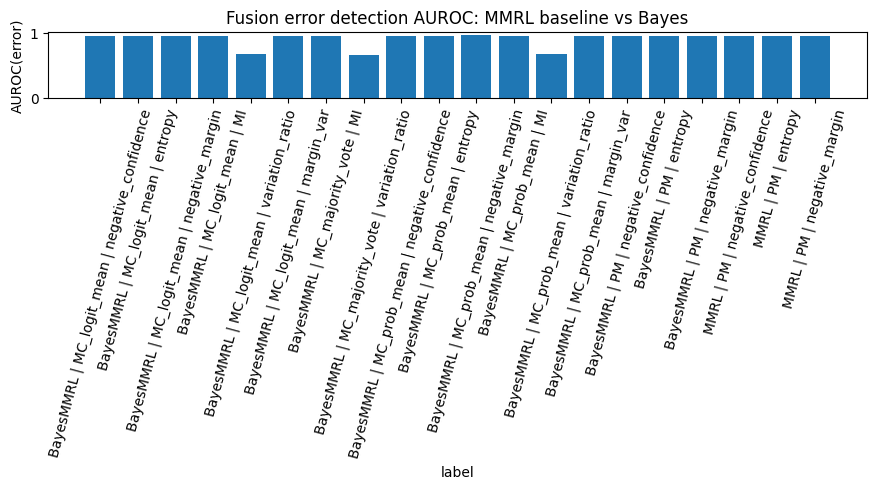

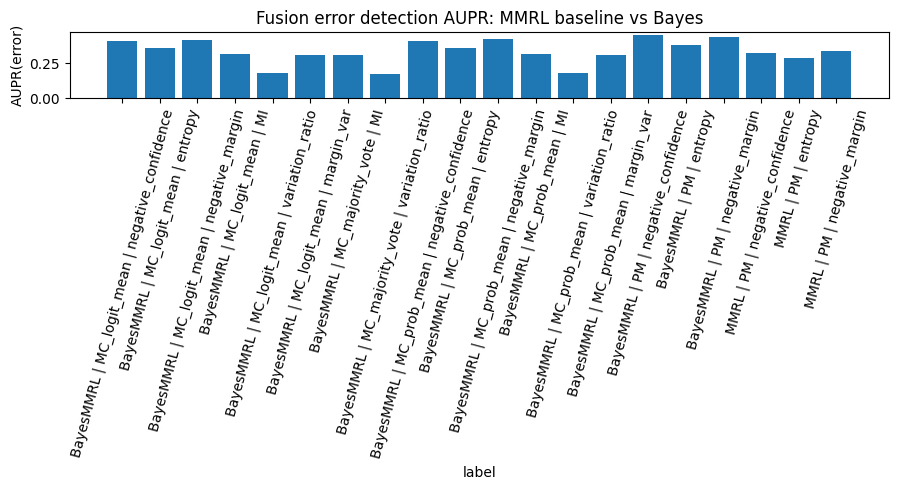

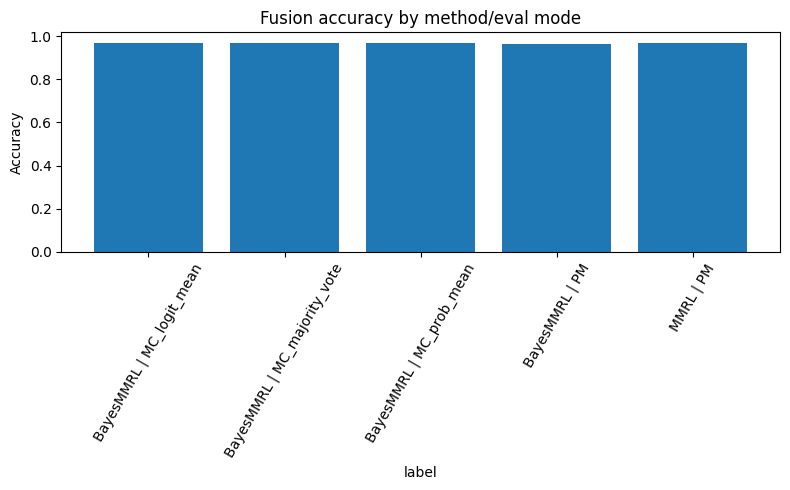

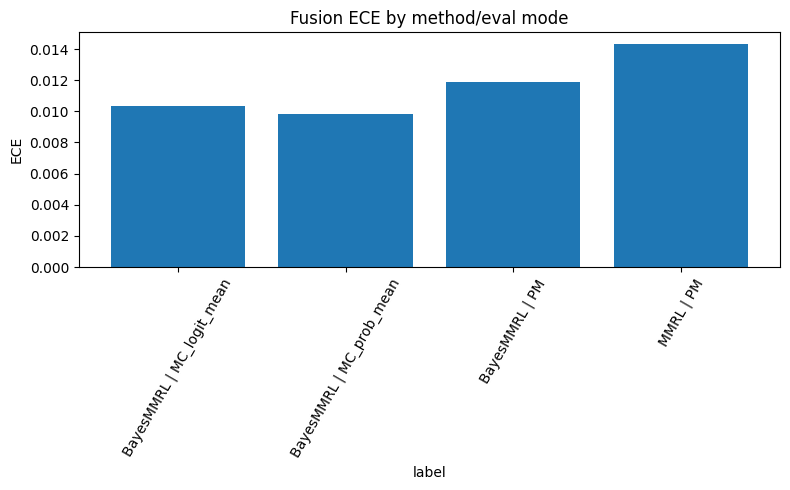

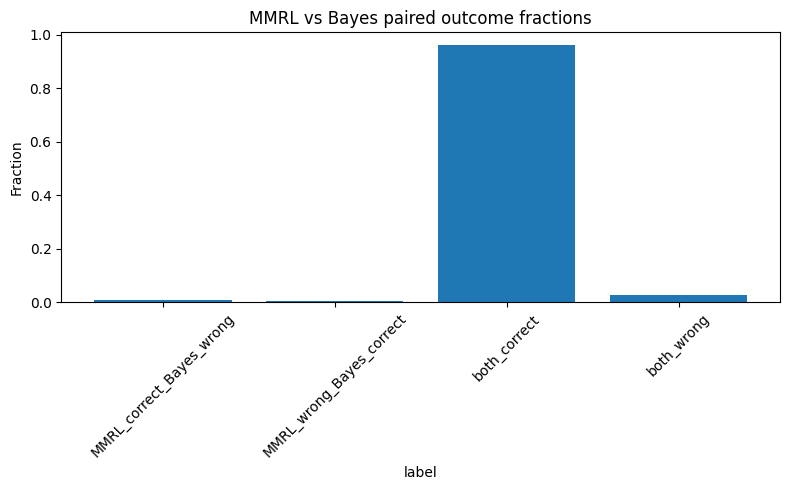

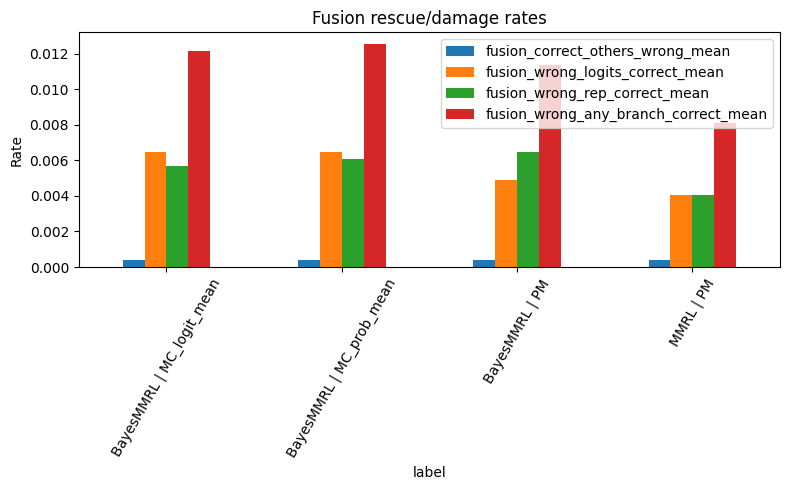

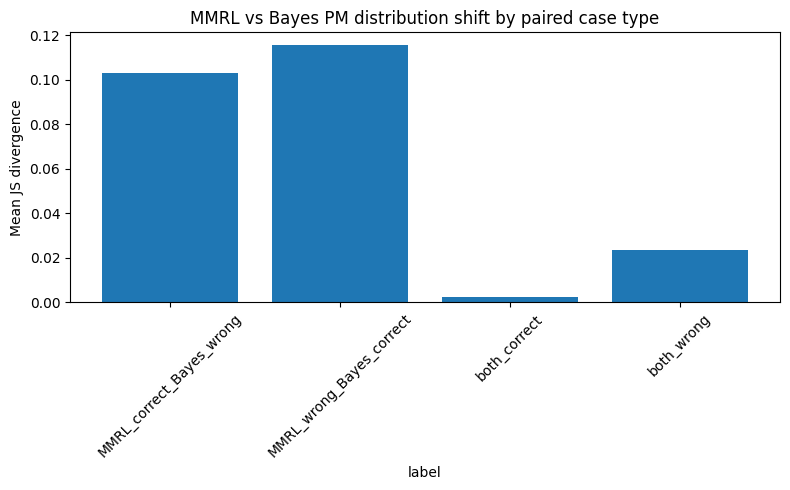

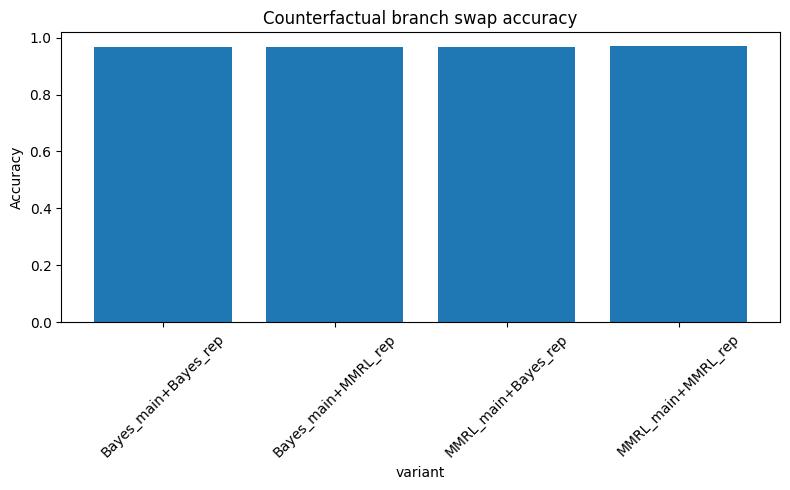

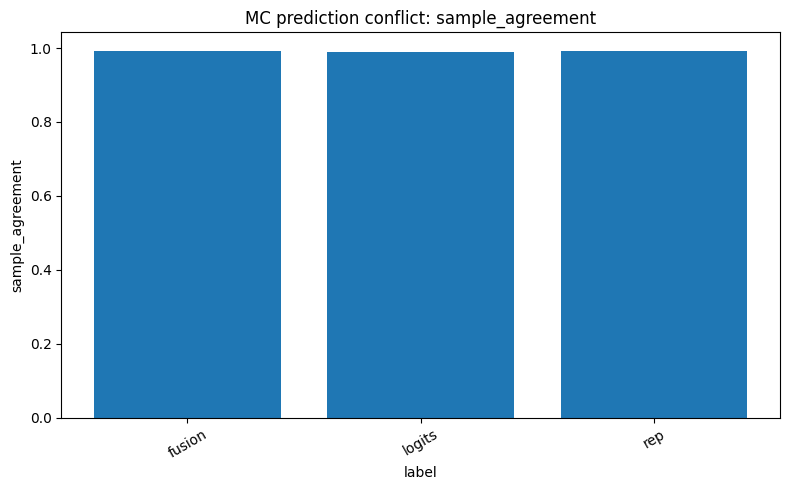

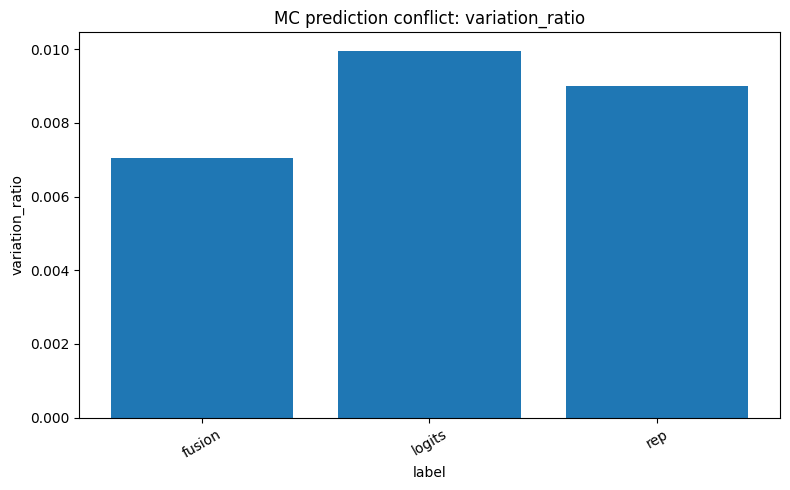

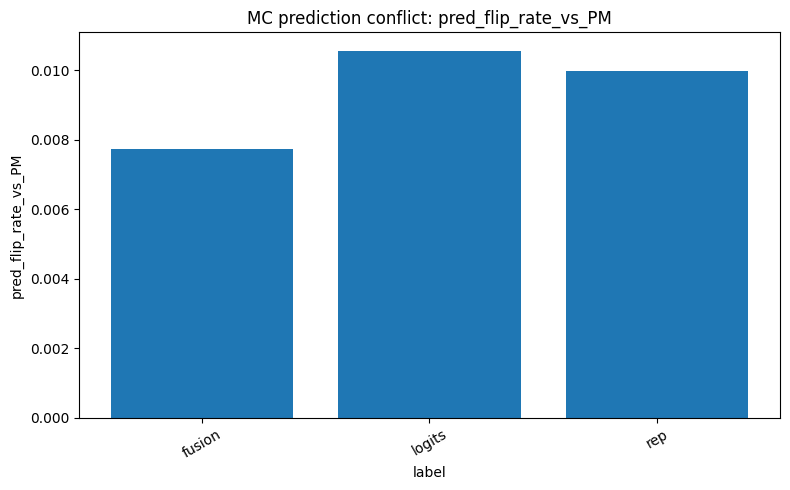

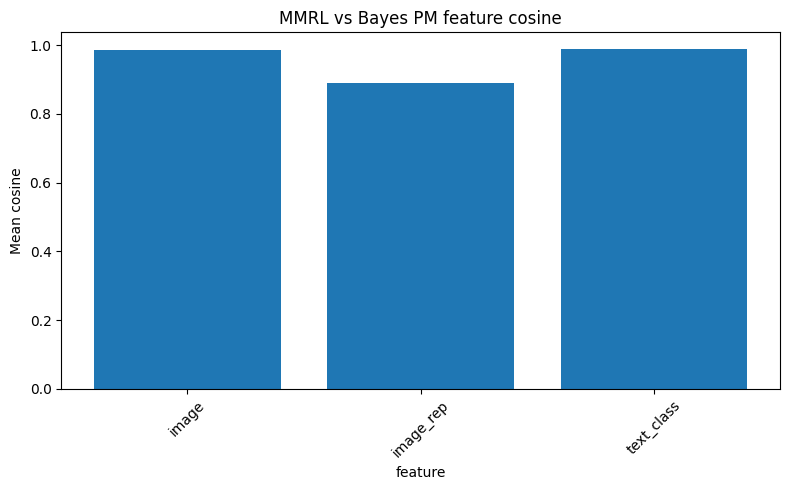

In [15]:
# =========================
# v3 visualizations
# =========================

def _v3_table(name):
    return complete_analysis_results.get(name, pd.DataFrame()) if "complete_analysis_results" in globals() else pd.DataFrame()

# Error detection AUROC / AUPR, including MMRL baseline.
ed = _v3_table("error_detection_metrics")
if not ed.empty:
    ed_show = ed[
        (ed["branch"] == "fusion")
        & (ed["score"].isin(["negative_confidence", "entropy", "negative_margin", "MI", "variation_ratio", "margin_var"]))
    ].copy()
    ed_show["label"] = ed_show["method"].astype(str) + " | " + ed_show["eval_mode"].astype(str) + " | " + ed_show["score"].astype(str)

    plot_bar_from_df(
        ed_show,
        x="label",
        y="AUROC_error",
        title="Fusion error detection AUROC: MMRL baseline vs Bayes",
        ylabel="AUROC(error)",
        rotation=75,
    )
    plot_bar_from_df(
        ed_show,
        x="label",
        y="AUPR_error",
        title="Fusion error detection AUPR: MMRL baseline vs Bayes",
        ylabel="AUPR(error)",
        rotation=75,
    )

# Branch metrics.
bm = _v3_table("branch_main_metrics")
if not bm.empty:
    bm2 = bm[bm["branch"] == "fusion"].copy()
    bm2["label"] = bm2["method"].astype(str) + " | " + bm2["eval_mode"].astype(str)
    plot_bar_from_df(
        bm2,
        x="label",
        y="acc",
        title="Fusion accuracy by method/eval mode",
        ylabel="Accuracy",
        rotation=60,
    )
    if "ECE" in bm2.columns:
        plot_bar_from_df(
            bm2.dropna(subset=["ECE"]),
            x="label",
            y="ECE",
            title="Fusion ECE by method/eval mode",
            ylabel="ECE",
            rotation=60,
        )

# Paired outcome.
po = _v3_table("paired_outcome_summary")
if not po.empty:
    po["label"] = po["case_type"].astype(str)
    plot_bar_from_df(
        po,
        x="label",
        y="fraction",
        title="MMRL vs Bayes paired outcome fractions",
        ylabel="Fraction",
        rotation=45,
    )

# Fusion damage.
fd = _v3_table("fusion_damage_summary")
if not fd.empty:
    cols = [
        "fusion_correct_others_wrong_mean",
        "fusion_wrong_logits_correct_mean",
        "fusion_wrong_rep_correct_mean",
        "fusion_wrong_any_branch_correct_mean",
    ]
    cols = [c for c in cols if c in fd.columns]
    fd2 = fd[(fd["eval_mode"].isin(["PM", "MC_prob_mean", "MC_logit_mean"]))].copy()
    fd2["label"] = fd2["method"].astype(str) + " | " + fd2["eval_mode"].astype(str)
    if cols:
        pivot = fd2.set_index("label")[cols]
        plot_grouped_bar(
            pivot,
            title="Fusion rescue/damage rates",
            ylabel="Rate",
            rotation=60,
        )

# Distribution shift.
ds = _v3_table("distribution_shift_summary")
if not ds.empty:
    ds2 = ds[ds["bayes_eval_mode"] == "PM"].copy()
    ds2["label"] = ds2["case_type"].astype(str)
    plot_bar_from_df(
        ds2,
        x="label",
        y="JS_mean",
        title="MMRL vs Bayes PM distribution shift by paired case type",
        ylabel="Mean JS divergence",
        rotation=45,
    )

# Counterfactual branch swap.
cf = _v3_table("counterfactual_branch_swap_summary")
if not cf.empty:
    plot_bar_from_df(
        cf,
        x="variant",
        y="acc",
        title="Counterfactual branch swap accuracy",
        ylabel="Accuracy",
        rotation=45,
    )

# MC conflict.
mc = _v3_table("mc_prediction_conflict_summary")
if not mc.empty:
    mc["label"] = mc["branch"].astype(str)
    for metric in ["sample_agreement", "variation_ratio", "pred_flip_rate_vs_PM"]:
        mean_col = metric
        if mean_col in mc.columns:
            plot_bar_from_df(
                mc,
                x="label",
                y=mean_col,
                title=f"MC prediction conflict: {metric}",
                ylabel=metric,
                rotation=30,
            )

# Feature similarity.
fs = _v3_table("feature_similarity_summary")
if not fs.empty:
    plot_bar_from_df(
        fs,
        x="feature",
        y="cosine_mean",
        title="MMRL vs Bayes PM feature cosine",
        ylabel="Mean cosine",
        rotation=45,
    )

## fixed4 patch note

修复内容：

- `confusion_samples` 生成时补上 `sample_index`；
- `confusion_pair_summary` 计数改为 `count=("pred_class", "size")`，不再依赖 `sample_index`；
- 保持最终输出仍只保存分析结果表，不保存 raw logits / MC samples / features。